# 06 · The events look-ahead

Do street festivals and club shows bring extra crime to the blocks around them, and can upcoming ones be
flagged ahead of time? This is `src/events_model.py`, run nightly by notebook `08b`. Two ideas carry it:

1. **Measuring a past event honestly**: observed crime around it against a carefully built *expected*.
2. **Scoring an upcoming one**: pool its own track record with what's typical for events like it
   (a Gamma-Poisson posterior), so one lucky edition doesn't decide it and a long history isn't ignored.

Pro sports are out of scope on purpose: everyone already plans around those.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent   # run from the repo root or tutorials/
sys.path[:0] = [str(ROOT), str(ROOT / "tutorials")]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import _data
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e1e0d9", "axes.prop_cycle": plt.cycler(color=["#2a78d6", "#eb6834", "#1baf7a", "#898781"])})
pd.set_option("display.width", 160, "display.max_columns", 30)
print("data from:", _data.source())

from datetime import date, timedelta

from scipy.stats import gamma

from src import events_model as em

data from: local exports


## 1. Observed vs. expected

Events happen in H3 cells (hexagons about 170 m across, resolution 9). For each past event, compare the
crime in its own cells and the ring around them on the event's days with an **expected** count:

- the same cells on the **same weekday, 1-4 weeks either side** (same place, same day-of-week rhythm);
- skipping control days that had any event nearby (otherwise busy corridors compare events with events);
- scaled by **how the whole city did** on the event day against those control days, which absorbs
  holidays, weather and citywide trend.

A toy version, one cell, with a planted festival that doubles its crime:

In [2]:
rng = np.random.default_rng(1)
days = pd.date_range("2025-05-01", "2025-08-31")
city = pd.Series(rng.poisson(650 * (1 + 0.15 * np.sin((days.dayofyear - 120) / 58))), index=days)   # citywide counts
cell = pd.Series(rng.poisson(city / 650 * 3.0), index=days)                                       # ~3 a day
event = pd.Timestamp("2025-07-12")
cell[event] = rng.poisson(city[event] / 650 * 3.0 * 2)                                               # the festival

controls = [event + pd.Timedelta(weeks=w) for w in (-4, -3, -2, -1, 1, 2, 3, 4)]
expected = cell[controls].mean() * city[event] / city[controls].mean()
print(f"observed {cell[event]}, expected {expected:.1f} -> ratio {cell[event] / expected:.2f}")

observed 5, expected 3.0 -> ratio 1.67


The planted 2x reads as less than that: one event is noisy. Pooled over every festival on record, the ratios are what the app reports
(`docs/modeling.md`): street festivals about **+31%** in their own cells, **+52%** for ones closing five or
more street segments, club nights about **+11%** before midnight. Checks that should read ~1.0 do: the day
before, the day after, and a placebo date five weeks later. In absolute terms that's about half an extra
crime per typical festival, so the look-ahead is a short filter for busy corridors, not an alarm.

## 2. Pooling a track record with a prior

An upcoming festival's likely lift should depend on its own past editions **and** on what festivals its
size usually do. The Gamma-Poisson model does exactly that: the prior is worth `b` expected crimes, and
the event's own history (observed O against expected E) is added on top:

posterior ratio = (O + b × prior) / (E + b)

With little history, the prior dominates; with a lot, the event speaks for itself. How big `b` is depends
on how much events *truly* differ beyond Poisson noise (the coefficient of variation, cv): `b = 1 / (prior × cv²)`.

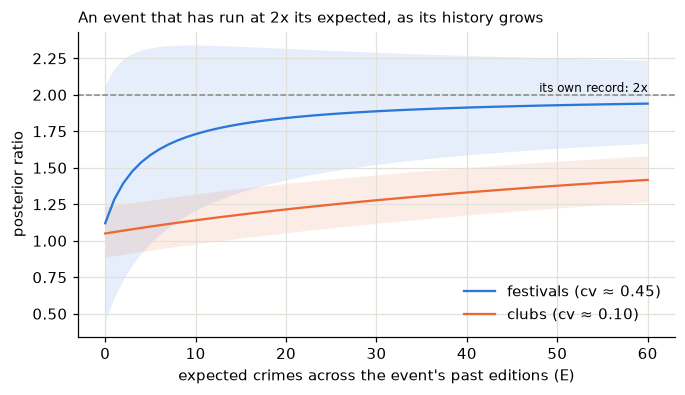

In [3]:
E = np.linspace(0, 60, 61)
fig, ax = plt.subplots(figsize=(7, 3.6))
for label, prior, cv in (("festivals (cv ≈ 0.45)", 1.12, 0.45), ("clubs (cv ≈ 0.10)", 1.05, 0.10)):
    df = em.posterior(pd.DataFrame({"O": 2.0 * E, "E": E, "prior": prior, "b": 1 / (prior * cv ** 2),
                                    "baseline_crime": 1.0}))
    ax.plot(E, df["ratio"], label=label)
    ax.fill_between(E, df["ratio_lo"], df["ratio_hi"], alpha=0.12)
ax.axhline(2.0, color="#898781", ls="--", lw=1); ax.text(60, 2.02, "its own record: 2x", ha="right", fontsize=8)
ax.set_xlabel("expected crimes across the event's past editions (E)"); ax.set_ylabel("posterior ratio")
ax.set_title("An event that has run at 2x its expected, as its history grows", loc="left", fontsize=10)
ax.legend(frameon=False); plt.show()

Festivals genuinely differ a lot (pub crawls stand out), so a few editions mostly speak for themselves.
Clubs barely differ beyond noise, so even a long record barely moves a club off the all-club average. The
model estimates cv from the data on every run (method of moments). On simulated groups with a known
spread, it recovers it:

In [4]:
true_cv, n_groups = 0.30, 400
lift = rng.gamma(1 / true_cv ** 2, true_cv ** 2 * 1.2, n_groups)        # true lifts around 1.2
items = []
for g in range(n_groups):
    for _ in range(rng.integers(2, 6)):                                   # a few editions each
        e = rng.uniform(2, 8)
        items.append({"group": g, "bucket": "all", "O": rng.poisson(lift[g] * e), "E": e})
items = pd.DataFrame(items)
print(f"true between-group cv {true_cv}, estimated {em.between_cv(items, ['group'], 'bucket'):.3f}")

true between-group cv 0.3, estimated 0.320


## 3. The real look-ahead

With the research exports on this machine (`offline_data/events/`), this runs the same code notebook
`08b` runs: the built event table, crime counts per cell (whole days for festivals; 6 pm-3 am for club
nights, with "time unknown" midnight records left out), the scored festivals and club nights, and the
priors it estimated.

In [5]:
events_dir = _data.OFFLINE / "events"
if not (events_dir / "events.parquet").exists() or _data.source() != "local exports":
    print("The research event exports aren't here; see offline_ml/README.md (Events) to build them.")
else:
    import glob
    events = pd.read_parquet(events_dir / "events.parquet")
    cells = pd.read_parquet(events_dir / "event_cells.parquet")
    for c in ("start_date", "end_date"):
        events[c] = pd.to_datetime(events[c]).dt.date
    snap = sorted(glob.glob(str(events_dir / "raw/ticketmaster/upcoming_*.parquet")))[-1]
    today = date.fromisoformat(snap.split("upcoming_")[1][:10])
    tm = pd.read_parquet(snap)

    fest, _ = em.upcoming_festivals(events)
    nights = em.upcoming_club_nights(events, tm, today)
    need = em.cells_needed(events, cells, fest, nights)
    cr = pd.read_parquet(_data.OFFLINE / "clean/crimes.parquet", columns=["occurred_at", "h3_r9"])
    cr = cr[(cr["occurred_at"] >= "2013-01-01") & cr["h3_r9"].isin(need)]
    ts = cr["occurred_at"]
    day = cr[~((ts.dt.day == 1) & (ts.dt.hour == 0) & (ts.dt.minute <= 1))].assign(date=lambda d: d["occurred_at"].dt.date)
    night = cr[((ts.dt.hour >= 18) | (ts.dt.hour < 3)) & ~((ts.dt.hour == 0) & (ts.dt.minute <= 1))]
    night = night.assign(date=(night["occurred_at"] - pd.Timedelta(hours=18)).dt.date)
    allc = pd.read_parquet(_data.OFFLINE / "clean/crimes.parquet", columns=["occurred_at"])
    allc = allc[allc["occurred_at"] >= "2013-01-01"]["occurred_at"]
    city_day = allc[~((allc.dt.day == 1) & (allc.dt.hour == 0) & (allc.dt.minute <= 1))].dt.date.value_counts()
    city_night = allc[((allc.dt.hour >= 18) | (allc.dt.hour < 3)) & ~((allc.dt.hour == 0) & (allc.dt.minute <= 1))]
    city_night = (city_night - pd.Timedelta(hours=18)).dt.date.value_counts()
    per_cell = lambda d: d.groupby(["h3_r9", "date"]).size().rename("crime").reset_index()
    as_city = lambda vc: vc.rename("crime").rename_axis("date").reset_index()

    out = em.lookahead(events, cells, tm, today, per_cell(day), as_city(city_day), per_cell(night), as_city(city_night))
    upcoming = em.upcoming_table(out, em.area_of_cells())
    print(f"as of {today}: {len(fest)} upcoming festivals and {len(nights)} club nights scored")
    display(out["priors"].round(3))
    display(upcoming[upcoming["kind"] == "festival"].sort_values("extra", ascending=False)
            .head(8)[["start_date", "name", "history", "baseline_crime", "ratio", "extra", "extra_lo", "extra_hi"]].round(2))

as of 2026-09-25: 89 upcoming festivals and 356 club nights scored


,bucket,n_past,prior,b,kind,cv
0,1,1864,1.093,4.636,festival,0.444
1,2-4,1046,1.121,4.518,festival,0.444
2,5+,271,1.296,3.908,festival,0.444
3,all,11244,1.053,100.533,club_night,0.097


,start_date,name,history,baseline_crime,ratio,extra,extra_lo,extra_hi
442,2027-03-13,The Shamrock Crawl,3,7.37,2.40,10.28,6.92,13.94
242,2026-10-31,Wrigleyville Halloween Crawl,4,13.22,1.53,7.05,1.46,13.38
401,2026-12-12,TBOX,6,5.51,1.95,5.21,2.38,8.40
70,2026-10-02,Apple Fest 2026,8,3.85,1.63,2.41,0.25,4.93
412,2026-12-31,Wrigleyville NYE Crawl,4,4.71,1.46,2.19,0.09,4.60
86,2026-10-03,Chicago Vintage Fest Pilsen,3,4.80,1.44,2.12,-0.61,5.42
319,2026-11-14,Randolph Street Market,8,5.90,1.23,1.37,-0.05,2.91
199,2026-10-23,St. Clement Halloween 2026,1,2.70,1.50,1.35,-0.68,3.94


Reading the output:
- **The priors table** is what each kind of event adds on average, and how much weight the prior gets
  (`b`, in expected crimes): small for festivals, about 100 for clubs.
- **The festival list** is led by pub crawls with a track record. Below the top few, most intervals
  include zero: individual events are uncertain, which is why the app shows a short list and an "impact"
  chip rather than a forecast for each one.
- Replaying 2017-2025 as of each January 1, the top 20% of this ranking captured 74% of the extra crime
  (`offline_ml/events_backtest.py`).

## What 08b adds

The nightly notebook builds the event table in Spark (`src/events_spark.py`, checked against this pandas
version by `tests/test_events_spark.py`), using Databricks' H3 SQL functions, then hands the counts to this
same scoring code and writes `events_upcoming` for the app and the agent.

Next: [07 · The agent and the app](07_agent_and_app.ipynb).